In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# Load the dataset
df = pd.read_csv('NTC.csv')

In [ ]:
df_raw = df.copy(deep=True)
# Display the first few rows of the dataset
df.head()

In [ ]:
#Check data types and missing values
df.info()

In [ ]:
#Cleaning the 'Percent Change' column
# Remove the '%' symbol from the 'Percent Change' column and regex=False to avoid treating it as a regex pattern
df['Percent Change'] = df['Percent Change'].str.replace('%', '', regex=False)
# Convert the 'Percent Change' column to numeric, coercing errors to NaN
df['Percent Change'] = pd.to_numeric(df['Percent Change'], errors='coerce')

In [ ]:
#Summary statistics
df.describe().T

In [ ]:
# Calculate the percentage of missing values for each column
missing_percent = df.isnull().mean() * 100
missing_percent

Missing value is less than 1% so we can ignore it.

In [ ]:
#Importing necessary libraries for modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [ ]:
# Define features and target variable
features = ['Open', 'High', 'Low', 'Volume', 'Percent Change']
X = df[features]
y = df['Close']
# Handle missing values by filling them with the mean of each column
X.fillna(X.mean(), inplace=True)    

C:\Users\acert\AppData\Local\Temp\ipykernel_12036\3211416131.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.fillna(X.mean(), inplace=True)


In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features for better performance of the linear regression model 
# StandardScaler standardizes features by removing the mean and scaling to unit variance, which can improve the performance of many machine learning algorithms, including linear regression.   
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# Train the linear regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)
# Make predictions on the test set
y_pred = model.predict(X_test_scaled)
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')   

Mean Squared Error: 44.74364223278896
R^2 Score: 0.9990584313335642


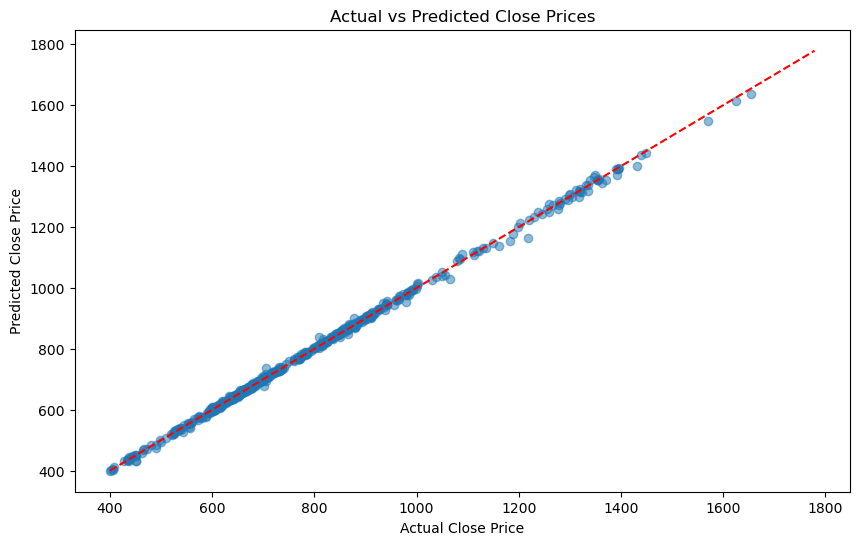

In [ ]:
#This shows the relationship between actual and predicted close prices. The closer the points are to the red dashed line, the better the model's predictions are. If the points are widely scattered around the line, it indicates that the model may not be performing well in predicting close prices accurately.
plt.figure(figsize=(10, 6))
plt.title('Actual vs Predicted Close Prices')
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual Close Price')    
plt.ylabel('Predicted Close Price')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # Line for perfect predictions
plt.show()